# Violin Plot

A violin plot compares the distribution of a numeric value across a few groups. Each group gets a smoothed outline of where its values fall, so the plot answers what a box plot cannot: *is the group one cluster or two, and where do its values pile up?* This guide shows how to create violin plots with the [datachart.charts.ViolinPlot](../../../references/charts/violinplot/#datachart.charts.ViolinPlot) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-violin-plot), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import ViolinPlot

## Basics

The examples in this guide share one dataset: the body mass of the 342 penguins with a recorded mass in the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset (CC0), three species measured on islands of the Palmer Archipelago in Antarctica. The data lives in a hidden cell. `penguins` holds one record per penguin: the species as `label`, the body mass in grams as `value`, and the `sex` of the bird (`None` for the few birds whose sex was not recorded). `flippers` holds the flipper length in millimeters of the same birds. The species differ in more than their average: Gentoo males and females are so far apart in mass that the Gentoo group has two peaks, and a box plot cannot show that.

In [2]:
# the 342 Palmer penguins with a recorded body mass, grouped by species and sex
PENGUINS = [
    {
        "species": "Adelie",
        "sex": "Female",
        "body_mass": [
            3800, 3250, 3450, 3625, 3200, 3700, 3450, 3325, 3400, 3800, 3800, 3200, 3150,
            3250, 3300, 3325, 3550, 3300, 3150, 3100, 3000, 3450, 3500, 3450, 2900, 3550,
            2850, 3150, 3600, 2850, 3350, 3050, 3600, 3550, 3700, 3700, 3550, 3200, 3800,
            3350, 3500, 3600, 3550, 3400, 3300, 3700, 2900, 3725, 3075, 2925, 3750, 3175,
            3825, 3200, 3900, 2900, 3350, 3150, 3450, 3050, 3275, 3050, 3325, 3500, 3425,
            3175, 3400, 3400, 3050, 3000, 3475, 3450, 3700,
        ],
        "flipper_length": [
            186, 195, 193, 181, 182, 185, 195, 184, 174, 189, 187, 187, 172, 178, 188, 195,
            180, 181, 182, 186, 185, 190, 186, 190, 187, 186, 181, 185, 185, 184, 195, 190,
            190, 196, 190, 191, 187, 189, 187, 191, 189, 190, 202, 185, 187, 190, 178, 192,
            183, 193, 199, 181, 198, 193, 191, 188, 189, 187, 176, 186, 191, 191, 190, 193,
            187, 191, 185, 193, 188, 192, 184, 195, 187,
        ],
    },
    {
        "species": "Adelie",
        "sex": "Male",
        "body_mass": [
            3750, 3650, 4675, 3800, 4400, 4500, 4200, 3600, 3950, 3800, 3550, 3950, 3900,
            3900, 4150, 3950, 4650, 3900, 4400, 4600, 3425, 4150, 4300, 4050, 3700, 3800,
            3750, 4400, 4050, 3950, 4100, 4450, 3900, 4150, 4250, 3900, 4000, 4700, 4200,
            3550, 3800, 3950, 4300, 4450, 4300, 4350, 4100, 4725, 4250, 3550, 3900, 4775,
            4600, 4275, 4075, 3775, 3325, 3500, 3875, 4000, 4300, 4000, 3500, 4475, 3900,
            3975, 4250, 3475, 3725, 3650, 4250, 3750, 4000,
        ],
        "flipper_length": [
            181, 190, 195, 191, 198, 197, 194, 180, 185, 180, 183, 180, 178, 184, 196, 190,
            184, 195, 196, 190, 182, 191, 188, 200, 191, 193, 194, 195, 192, 192, 188, 198,
            190, 197, 195, 184, 195, 196, 193, 194, 190, 189, 205, 186, 208, 196, 192, 203,
            190, 184, 190, 197, 191, 197, 196, 199, 189, 198, 202, 199, 195, 210, 197, 199,
            190, 200, 193, 187, 190, 185, 190, 193, 201,
        ],
    },
    {
        "species": "Adelie",
        "sex": None,
        "body_mass": [
            3475, 4250, 3300, 3700, 2975,
        ],
        "flipper_length": [
            193, 190, 186, 180, 179,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Female",
        "body_mass": [
            3500, 3525, 3950, 3250, 4150, 3800, 3700, 3575, 3700, 3450, 3600, 2900, 3300,
            3400, 3700, 3200, 3350, 3900, 3850, 2700, 3650, 3500, 3675, 3400, 3675, 3325,
            3600, 3350, 3250, 3525, 3650, 3650, 3400, 3775,
        ],
        "flipper_length": [
            192, 188, 198, 178, 195, 193, 185, 190, 181, 190, 181, 187, 195, 200, 191, 187,
            187, 199, 195, 192, 187, 196, 196, 190, 198, 199, 193, 187, 191, 194, 189, 195,
            202, 198,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Male",
        "body_mass": [
            3900, 3650, 3725, 3750, 3700, 3775, 4050, 4050, 3300, 4400, 3400, 3800, 4150,
            3800, 4550, 4300, 4100, 3600, 4800, 4500, 3950, 3550, 4450, 4300, 3250, 3950,
            4050, 3450, 4050, 3800, 3950, 4000, 3775, 4100,
        ],
        "flipper_length": [
            196, 193, 197, 197, 198, 194, 201, 201, 197, 195, 191, 193, 197, 200, 205, 201,
            203, 195, 210, 205, 210, 196, 201, 212, 187, 201, 203, 197, 203, 202, 206, 207,
            193, 210,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Female",
        "body_mass": [
            4500, 4450, 4550, 4800, 4400, 4650, 4650, 4200, 4150, 4800, 5000, 4400, 5000,
            4600, 4700, 5050, 5150, 4950, 4350, 3950, 4300, 4900, 4200, 5100, 4850, 4400,
            4900, 4300, 4450, 4200, 4400, 4700, 4700, 4750, 5200, 4700, 4600, 4750, 4625,
            4725, 4750, 4600, 4875, 4950, 4750, 4850, 4875, 4625, 4850, 4975, 4700, 4575,
            5000, 4650, 4375, 4925, 4850, 5200,
        ],
        "flipper_length": [
            211, 210, 210, 211, 209, 214, 214, 210, 210, 209, 215, 213, 215, 210, 209, 207,
            220, 213, 208, 208, 210, 217, 210, 213, 210, 210, 217, 208, 208, 208, 214, 219,
            220, 216, 217, 216, 209, 215, 212, 212, 212, 218, 212, 218, 212, 214, 222, 203,
            219, 215, 210, 208, 216, 213, 217, 214, 215, 212,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Male",
        "body_mass": [
            5700, 5700, 5400, 5200, 5150, 5550, 5850, 5850, 6300, 5350, 5700, 5050, 5100,
            5650, 5550, 5250, 6050, 5400, 5250, 5350, 5700, 4750, 5550, 5400, 5300, 5300,
            5000, 5050, 5000, 5550, 5300, 5650, 5700, 5800, 5550, 5000, 5100, 5800, 6000,
            5950, 5450, 5350, 5600, 5300, 5550, 5400, 5650, 5200, 4925, 5250, 5600, 5500,
            5500, 5500, 5500, 5950, 5500, 5850, 6000, 5750, 5400,
        ],
        "flipper_length": [
            230, 218, 215, 219, 215, 216, 213, 217, 221, 222, 218, 215, 215, 215, 220, 222,
            230, 220, 219, 208, 225, 216, 222, 225, 215, 220, 225, 220, 220, 224, 221, 231,
            230, 229, 223, 221, 221, 230, 220, 223, 221, 224, 228, 218, 230, 228, 224, 226,
            216, 225, 228, 228, 215, 219, 209, 229, 230, 230, 222, 222, 213,
        ],
    },
    {
        "species": "Gentoo",
        "sex": None,
        "body_mass": [
            4100, 4650, 4725, 4875,
        ],
        "flipper_length": [
            216, 214, 216, 217,
        ],
    },
]

penguins = [
    {"label": group["species"], "value": mass, "sex": group["sex"]}
    for group in PENGUINS
    for mass in group["body_mass"]
]
flippers = [
    {"label": group["species"], "value": length, "sex": group["sex"]}
    for group in PENGUINS
    for length in group["flipper_length"]
]

Each data point is one observation, a dictionary with a `label` (the group) and a `value`. The points that share a `label` form one violin, so three species give three violins; extra keys such as `sex` are ignored until a parameter asks for them:

In [3]:
penguins[:3]

[{'label': 'Adelie', 'value': 3800, 'sex': 'Female'},
 {'label': 'Adelie', 'value': 3250, 'sex': 'Female'},
 {'label': 'Adelie', 'value': 3450, 'sex': 'Female'}]

**Basic example.** Only the `data` argument is required. Each body is a kernel density estimate of its group's values (a smoothed histogram), mirrored around the group's position, so the body is wide where many penguins share a mass and thin where few do. Inside it, a thin bar spans the middle half of the values (the first to the third quartile), the line through it reaches the furthest values within 1.5 times the bar length, and the dot is the median. The Gentoo body is pinched at the waist: two clusters of birds, with fewer in between.

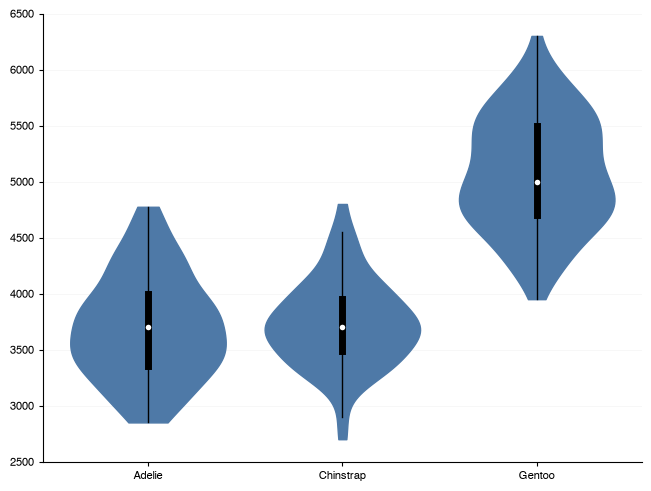

In [4]:
ViolinPlot(
    # add the data to the chart
    data=penguins
).show()

## Customizing the Violin Plot

Every customization is either a keyword argument of `ViolinPlot` or a `plot_violin_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                    | Use                                                                 | See |
| :-------------------------------------------- | :------------------------------------------------------------------ | :-- |
| add a title and axis labels                   | `title`, `xlabel`, `ylabel`                                         | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| format or place the ticks                     | `yticks_format`, `yticks`, `xtickrotate`                            | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| fix the axis range                            | `xmin`, `xmax`, `ymin`, `ymax`                                      | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| resize the figure                             | `figsize`                                                           | [Figure size and grid](#figure-size-and-grid) |
| show grid lines                               | `show_grid`                                                         | [Figure size and grid](#figure-size-and-grid) |
| fix the aspect ratio of the axes              | `aspect_ratio`                                                      | [Figure size and grid](#figure-size-and-grid) |
| change what is drawn inside the body          | `inner`                                                             | [Inner marks](#inner-marks) |
| smooth or sharpen the body                    | `bandwidth`                                                         | [Bandwidth](#bandwidth) |
| compare two subgroups within each violin      | `split`, `show_legend`                                              | [Split violins](#split-violins) |
| title and place the legend                    | `legend`                                                            | [Legend](#legend) |
| print the median of each violin               | `show_values`, `value_format`                                       | [Value labels](#value-labels) |
| change the body fill, edge, width, or hatch   | `style={"plot_violin_color": ..., "plot_violin_width": ...}`        | [Violin style](#violin-style) |
| style the inner marks and the median dot      | `style={"plot_violin_inner_color": ..., "plot_violin_median_color": ...}` | [Violin style](#violin-style) |
| draw the violins horizontally                 | `orientation`                                                       | [Horizontal violins](#horizontal-violins) |
| highlight some violins, mute the rest         | `emphasis`, `emphasis_rule`                                         | [Emphasis](#emphasis) |
| mark a threshold or shade a range             | `hlines`, `dlines`, `vlines`, `hspans`, `vspans`                  | [Reference lines and bands](#reference-lines-and-bands) |
| put a note on the chart                       | `texts`                                                             | [Text annotations](#text-annotations) |
| use dates as group labels                     | `date` objects as `label`, `xticks_format`                          | [Date labels](#date-labels) |
| draw a box plot or the observations over the violins | `Panel` with `BoxPlot` or `SwarmPlot`                        | [Violins with boxes and swarms](#violins-with-boxes-and-swarms) |
| compare several datasets side by side         | `data` as a list of lists, `subtitle`, `subplots`                   | [Multiple Violin Plots](#multiple-violin-plots) |
| arrange the subplots and share their axes     | `max_cols`, `sharex`, `sharey`                                      | [Shared axes across subplots](#shared-axes-across-subplots) |
| use a logarithmic value axis                  | `scaley`                                                            | [Axis scales](#axis-scales) |
| label the ticks of transformed values         | `yticks`, `yticklabels`                                             | [Axis scales](#axis-scales) |
| plot data with other key names                | `label`, `value`                                                    | [Custom data keys](#custom-data-keys) |
| save the chart to a file                      | `save_figure`                                                       | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `orientation` | [`ORIENTATION`](../../../references/constants/#datachart.constants.ORIENTATION) |
| `sort` | [`SORT`](../../../references/constants/#datachart.constants.SORT) |
| `scaley` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `yticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `inner` | [`VIOLIN_INNER`](../../../references/constants/#datachart.constants.VIOLIN_INNER) |
| `bandwidth` | [`BANDWIDTH`](../../../references/constants/#datachart.constants.BANDWIDTH) |

The full list of style attributes is in the [datachart.typings.ViolinStyleAttrs](../../../references/charts/violinplot/#datachart.typings.ViolinStyleAttrs) type; the full list of parameters is in the [datachart.charts.ViolinPlot](../../../references/charts/violinplot/#datachart.charts.ViolinPlot) reference.

### Title, axis labels and ticks

A violin without labels leaves the reader guessing what is being measured and in which unit; `title`, `xlabel` and `ylabel` say it. Masses in the thousands read easier with a thousands separator, which `yticks_format` adds with any `"{x:,.0f}"` style string, and `yticks` places the ticks at round values. `ymin` and `ymax` fix the value range; each body ends at its lightest and heaviest bird, so a range with a margin keeps the tips off the frame.

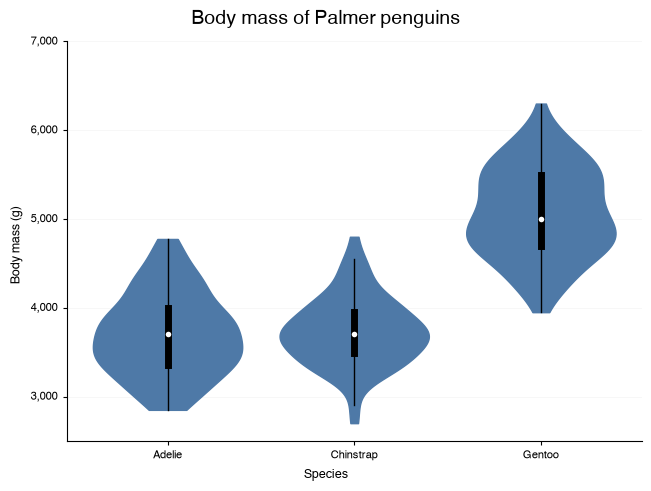

In [5]:
ViolinPlot(
    data=penguins,
    # add the title
    title="Body mass of Palmer penguins",
    # add the x and y axis labels
    xlabel="Species",
    ylabel="Body mass (g)",
    # thousands separator on the value axis, one tick per 1,000 g
    yticks_format="{x:,.0f}",
    yticks=[3000, 4000, 5000, 6000, 7000],
    # fix the value range, with a margin around the tips
    ymin=2500,
    ymax=7000,
).show()

### Figure size and grid

The default figure is nearly square, while three violins read well in a wide, short figure that fits the width of a page. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE). Grid lines let the eye carry a median or a peak across to the value axis: [SHOW_GRID.Y](../../../references/constants/#datachart.constants.SHOW_GRID) draws them along the values only, which is all a vertical violin needs. `aspect_ratio` fixes the ratio of the axes rather than of the figure ([ASPECT_RATIO](../../../references/constants/#datachart.constants.ASPECT_RATIO)); violins rarely need it, so the examples leave it at the default.

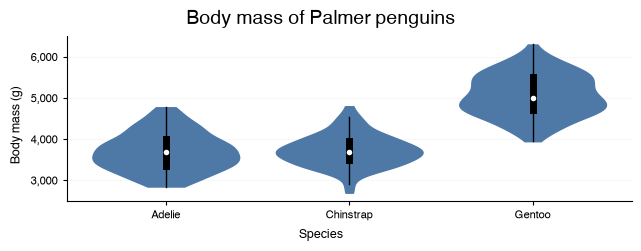

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

ViolinPlot(
    data=penguins,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    yticks_format="{x:,.0f}",
    # a wide, short figure
    figsize=FIG_SIZE.FULL_SHORT,
    # grid lines along the value axis only
    show_grid=SHOW_GRID.Y,
).show()

### Inner marks

The body shows the shape, and the marks inside it give the numbers to read against: where the median is, and where the middle half of the birds sits. `inner` picks them from [VIOLIN_INNER](../../../references/constants/#datachart.constants.VIOLIN_INNER): `VIOLIN_INNER.BOX` (the default) draws a thin quartile bar, a whisker line and a median dot, the summary of a box plot; `VIOLIN_INNER.QUARTILES` draws a dashed median and dotted quartile lines across the body, which keep the shape in view; `VIOLIN_INNER.MEDIAN` draws the median line alone; `None` draws the body only. The quartile lines show what the box hides: the Gentoo median falls near the waist of the body, between the two clusters, where fewer birds actually sit.

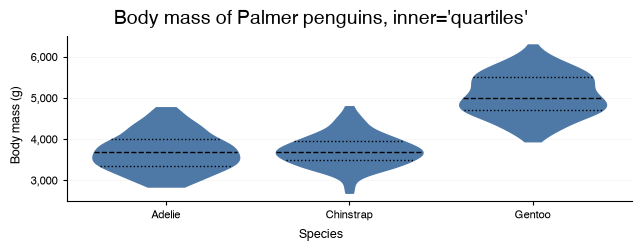

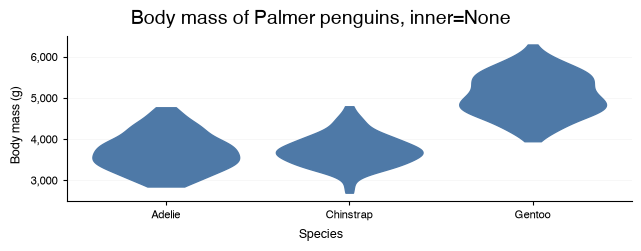

In [7]:
from datachart.constants import VIOLIN_INNER

for inner in [VIOLIN_INNER.QUARTILES, None]:
    ViolinPlot(
        data=penguins,
        # the marks drawn inside each body
        inner=inner,
        title=f"Body mass of Palmer penguins, inner={inner!r}",
        xlabel="Species",
        ylabel="Body mass (g)",
        yticks_format="{x:,.0f}",
        figsize=FIG_SIZE.FULL_SHORT,
        show_grid=SHOW_GRID.Y,
    ).show()

### Bandwidth

The body is a smoothed estimate, and how much it is smoothed decides what the reader sees. `bandwidth` sets the width of the smoothing kernel: a rule of thumb from [BANDWIDTH](../../../references/constants/#datachart.constants.BANDWIDTH) (`BANDWIDTH.SCOTT`, the default, or `BANDWIDTH.SILVERMAN`, which is nearly the same), or a number that scales the spread of the values. Too small a number follows every clump of repeated masses (penguins were weighed to the nearest 25 or 50 g) and draws bumps that are noise; too large a number irons the Gentoo body into a single hump and hides the two clusters that make it interesting. The summary marks do not change, because they are computed from the values, not from the estimate.

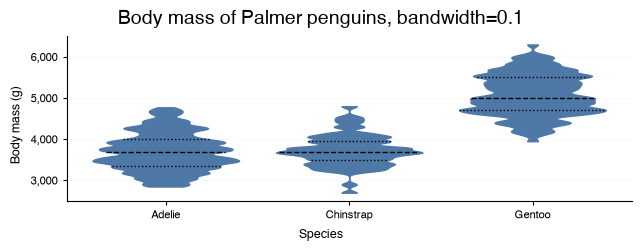

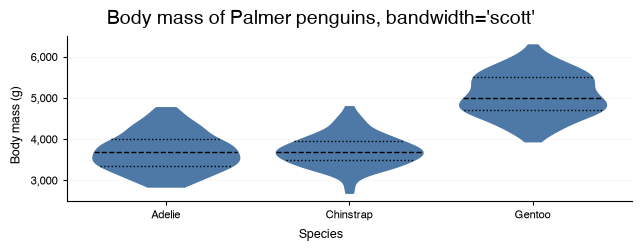

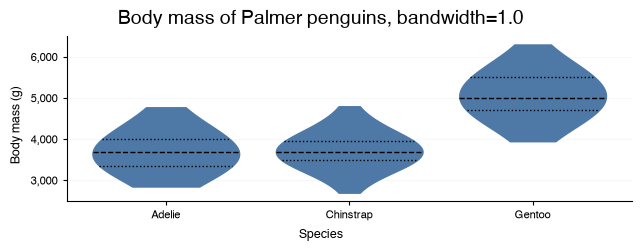

In [8]:
from datachart.constants import BANDWIDTH

for bandwidth in [0.1, BANDWIDTH.SCOTT, 1.0]:
    ViolinPlot(
        data=penguins,
        # the width of the smoothing kernel
        bandwidth=bandwidth,
        inner=VIOLIN_INNER.QUARTILES,
        title=f"Body mass of Palmer penguins, bandwidth={bandwidth!r}",
        xlabel="Species",
        ylabel="Body mass (g)",
        yticks_format="{x:,.0f}",
        figsize=FIG_SIZE.FULL_SHORT,
        show_grid=SHOW_GRID.Y,
    ).show()

### Split violins

The Gentoo waist asks a question: what are the two clusters? A split violin answers it by cutting each violin in half along a second variable. `split` names the key whose values pick the half; it must take **exactly two** values across the data, the first one seen draws on the left and the second on the right, each half in its own color and with its own inner marks, and `show_legend` names the halves. Split by `sex`, the two Gentoo clusters turn out to be the females and the males, and the males of every species are heavier. The birds with no recorded sex would be a third value, so they are dropped first.

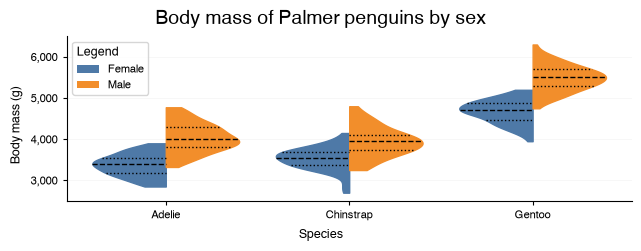

In [9]:
sexed = [penguin for penguin in penguins if penguin["sex"] is not None]

ViolinPlot(
    data=sexed,
    # the left half holds the females, the right half the males
    split="sex",
    inner=VIOLIN_INNER.QUARTILES,
    # name the two halves
    show_legend=True,
    title="Body mass of Palmer penguins by sex",
    xlabel="Species",
    ylabel="Body mass (g)",
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Legend

The default legend lands where the theme puts it, which may cover a body. `legend` says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols`, and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN); a field left out falls back to the theme ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). The heavy Gentoo violin fills the upper right, so a titled legend in the upper left, in one row, stays clear of it.

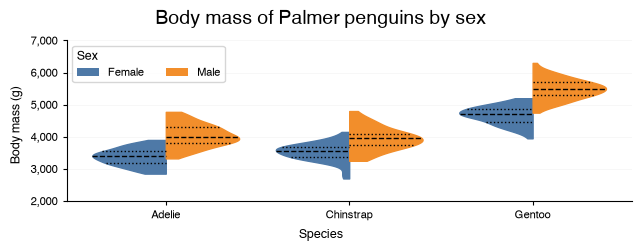

In [10]:
from datachart.constants import LEGEND_LOCATION

ViolinPlot(
    data=sexed,
    split="sex",
    inner=VIOLIN_INNER.QUARTILES,
    show_legend=True,
    # a titled legend in one row, clear of the Gentoo violin
    legend={"title": "Sex", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    title="Body mass of Palmer penguins by sex",
    xlabel="Species",
    ylabel="Body mass (g)",
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    ymax=7000,
).show()

### Value labels

When the exact center matters, `show_values` prints each violin's median beside its median mark, and `value_format` formats it: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:,.0f}"` style string. With `split`, each half prints its own median, so the gap between the sexes can be read off directly. The label font size, color and padding are the `plot_value_*` style attributes ([ValueLabelStyleAttrs](../../../references/typings/#datachart.typings.ValueLabelStyleAttrs)).

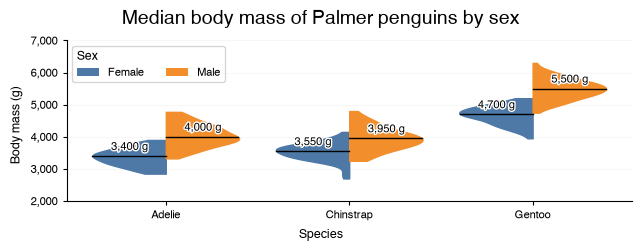

In [11]:
ViolinPlot(
    data=sexed,
    split="sex",
    inner=VIOLIN_INNER.MEDIAN,
    show_legend=True,
    legend={"title": "Sex", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    # print the median of each half
    show_values=True,
    value_format="{x:,.0f} g",
    style={"plot_value_fontsize": 8},
    title="Median body mass of Palmer penguins by sex",
    xlabel="Species",
    ylabel="Body mass (g)",
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    ymax=7000,
).show()

### Violin style

The `style` dictionary sets the look of every violin of the chart: `plot_violin_color`, `plot_violin_alpha`, `plot_violin_edgecolor`, `plot_violin_linewidth` and `plot_violin_hatch` style the body, `plot_violin_width` sets its maximum width, the `plot_violin_inner_*` attributes style the marks inside it and the `plot_violin_median_*` attributes the median dot; the attributes are listed in [datachart.typings.ViolinStyleAttrs](../../../references/charts/violinplot/#datachart.typings.ViolinStyleAttrs), and any attribute left out keeps the value of the active theme. A chart that will be printed in greyscale needs to survive without color: a light fill with a dark edge, a hatch from [HATCH_STYLE](../../../references/constants/#datachart.constants.HATCH_STYLE), and a red median dot that stands out on the dark quartile bar.

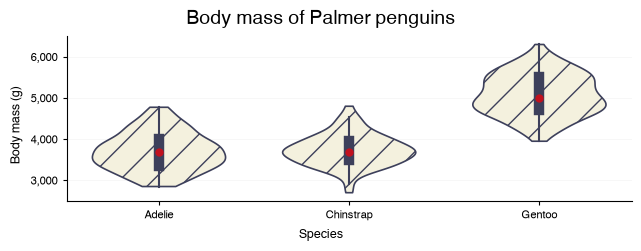

In [12]:
from datachart.constants import HATCH_STYLE

ViolinPlot(
    data=penguins,
    # a print-safe look: light hatched bodies with a dark edge
    style={
        "plot_violin_color": "#f4f1de",
        "plot_violin_alpha": 1.0,
        "plot_violin_edgecolor": "#3d405b",
        "plot_violin_linewidth": 1.2,
        "plot_violin_hatch": HATCH_STYLE.DIAGONAL,
        "plot_violin_width": 0.7,
        "plot_violin_inner_color": "#3d405b",
        "plot_violin_inner_linewidth": 1.5,
        "plot_violin_median_color": "#c1121f",
        "plot_violin_median_size": 6,
    },
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Horizontal violins

Horizontal violins read like a set of distributions stacked on a shared scale, and long group names stay readable without rotation. `orientation=ORIENTATION.HORIZONTAL` ([ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION)) puts the groups on the y-axis and the values on the x-axis, so the axis labels, the tick format and the grid swap with it. The first group is drawn at the bottom.

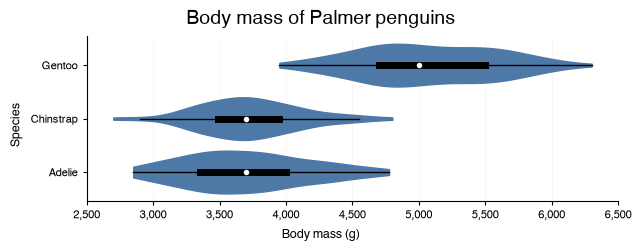

In [13]:
from datachart.constants import ORIENTATION

ViolinPlot(
    data=penguins,
    # draw the violins horizontally
    orientation=ORIENTATION.HORIZONTAL,
    title="Body mass of Palmer penguins",
    # the axis labels, the tick format and the grid swap with the orientation
    xlabel="Body mass (g)",
    ylabel="Species",
    xticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.X,
).show()

### Emphasis

A chart usually makes one point, and emphasis makes it visible. `emphasis` takes one role per violin, aligned with the groups in the order they first appear in the data (here Adelie, Chinstrap, Gentoo): `"highlight"` bolds the body edge, `"background"` mutes the body and its inner marks, `None` leaves it as it is. A single role applies to every violin. The roles are also available as the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants, and the [Highlighting](../../styling/highlighting/) guide covers emphasis across every chart type and theme. Adelie and Chinstrap penguins weigh about the same, and muting the Gentoo makes that the point.

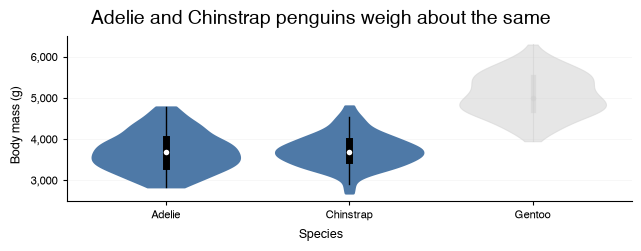

In [14]:
from datachart.constants import EMPHASIS

ViolinPlot(
    data=penguins,
    # one role per group: Adelie, Chinstrap, Gentoo
    emphasis=[EMPHASIS.HIGHLIGHT, EMPHASIS.HIGHLIGHT, EMPHASIS.BACKGROUND],
    title="Adelie and Chinstrap penguins weigh about the same",
    xlabel="Species",
    ylabel="Body mass (g)",
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

`emphasis_rule` picks the violins from the data instead of by position. It is a one-key dictionary read against a summary of each group: `{"top": n}` or `{"bottom": n}` by rank, `{"above": v}` or `{"below": v}` (strict), or `{"between": (lo, hi)}` (inclusive). The summary is the median by default, the value the inner marks already show; a `"by"` key picks `"mean"`, `"min"`, `"max"` or `"sum"` instead. An explicit `emphasis` role wins over the rule. The rule below highlights every species whose heaviest bird tops 5,000 g:

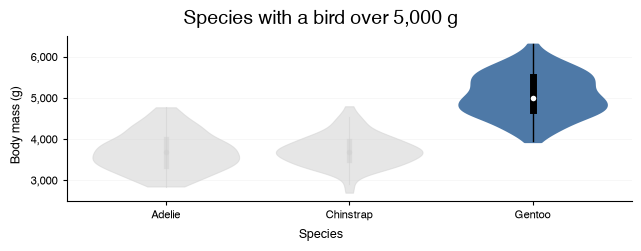

In [15]:
ViolinPlot(
    data=penguins,
    # read the rule against the heaviest bird of each species
    emphasis_rule={"above": 5000, "by": "max"},
    title="Species with a bird over 5,000 g",
    xlabel="Species",
    ylabel="Body mass (g)",
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Reference lines and bands

Reference lines and bands put the violins in context. `hlines` draws a horizontal line at a value, such as the mean of all birds, and `vlines` a vertical one; the violins sit at positions `0`, `1`, `2`, … along the group axis, as bars do, so a half-integer falls between two violins. `hspans` and `vspans` shade a range instead of marking a value. Each takes a dictionary or a list of them, with the position, an optional `label` for the legend and a `style`; the keys are listed in [HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs), [VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs) and [VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs). The example marks the mean of all 342 birds and shades one standard deviation around it: the mean falls in the gap between the lighter species and the Gentoo, where few birds of any species sit, which is why a single average describes none of them well.

`dlines` completes the trio. Where `vlines` fixes an x and `hlines` a y, a diagonal is fixed by a `slope` and an `intercept`, so it runs through the data space instead of across it; `dlines={}` on its own draws the parity line `y = x`. It spans the axes unless `xmin` and `xmax` clip it to a segment, and takes the same optional `label` and `style`; the keys are listed in [DLineSettingAttrs](../../../references/typings/#datachart.typings.DLineSettingAttrs). The violins sit at `0`, `1`, `2`, so a diagonal asks whether the species step up evenly: the line runs from the first mean to the last, and the middle violin sits below it.

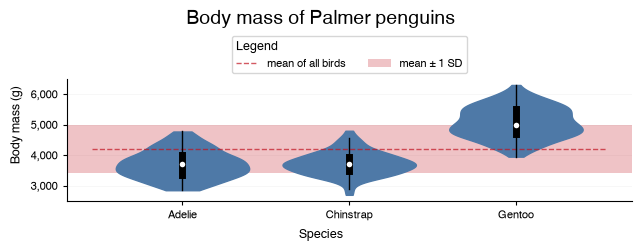

In [16]:
from statistics import mean, pstdev

from datachart.constants import LINE_STYLE

masses = [penguin["value"] for penguin in penguins]
mass_mean, mass_sd = mean(masses), pstdev(masses)

ViolinPlot(
    data=penguins,
    # a dashed line at the mean of all birds
    hlines={
        "y": mass_mean,
        "label": "mean of all birds",
        "style": {"plot_hline_color": "#c1121f", "plot_hline_style": LINE_STYLE.DASHED},
    },
    # shade one standard deviation around it
    hspans={
        "ymin": mass_mean - mass_sd,
        "ymax": mass_mean + mass_sd,
        "label": "mean ± 1 SD",
        "style": {"plot_hspan_color": "#c1121f"},
    },
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    # one row above the axes, clear of the band
    legend={"location": LEGEND_LOCATION.OUTSIDE_TOP, "ncols": 2},
).show()

In [ ]:
species = list(dict.fromkeys(penguin["label"] for penguin in penguins))
means = [
    mean(penguin["value"] for penguin in penguins if penguin["label"] == name)
    for name in species
]
# an even step from the first species to the last
even_step = (means[-1] - means[0]) / (len(species) - 1)

ViolinPlot(
    data=penguins,
    # the line the means would sit on if the species stepped up evenly
    dlines={
        "slope": even_step,
        "intercept": means[0],
        "label": "even step between species",
        "style": {"plot_dline_color": "#1d3557", "plot_dline_style": LINE_STYLE.DASHED},
    },
    title="Body mass of Palmer penguins against an even step",
    xlabel="Species",
    ylabel="Body mass (g)",
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Text annotations

Where a reference line marks a value, a note explains a shape. `texts` places text on the chart, with an optional `target` to draw a connector to a point; the position is in data coordinates by default (group position, value) or in axes fractions with `"coords": "axes"`, which keeps the note in place whatever the axis limits. The [Text Annotations](../../utility/annotations/) guide covers placement, connector looks and styling. The note below points at the Gentoo waist and says what it is.

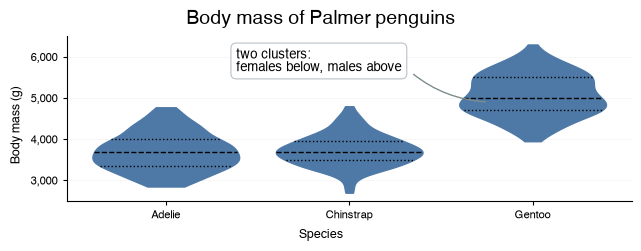

In [17]:
ViolinPlot(
    data=penguins,
    inner=VIOLIN_INNER.QUARTILES,
    # a note pinned to the axes, pointing at the Gentoo waist
    texts={
        "text": "two clusters:\nfemales below, males above",
        "x": 0.3,
        "y": 0.85,
        "coords": "axes",
        # the Gentoo violin sits at position 2
        "target": (1.78, 4900),
    },
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Date labels

Groups are often periods: months, quarters, sampling campaigns. A `label` that is a real temporal object (`datetime`, `date`, `numpy.datetime64` or a pandas `Timestamp`) keeps its group position but prints through `xticks_format`, a [DATE_FORMAT](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern. `daily_temperatures`, defined in a hidden cell, holds 30 illustrative daily mean temperatures per month, drawn around the 1991–2020 monthly normals of Ljubljana and labeled by the first day of each month. The violins show the seasonal cycle, and that winter days vary more than summer days.

In [18]:
from datetime import date

import numpy as np

# 1991-2020 monthly mean temperature normals of Ljubljana, in °C
MONTHLY_MEAN = [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.6, 11.5, 5.9, 1.3]
# an illustrative day-to-day spread, wider in winter
MONTHLY_SPREAD = [4.0, 4.0, 3.5, 3.0, 2.5, 2.5, 2.5, 2.5, 3.0, 3.5, 3.5, 4.0]

rng = np.random.RandomState(42)
daily_temperatures = [
    {"label": date(2024, month, 1), "value": round(float(temperature), 1)}
    for month, center, spread in zip(range(1, 13), MONTHLY_MEAN, MONTHLY_SPREAD)
    for temperature in rng.normal(center, spread, 30)
]

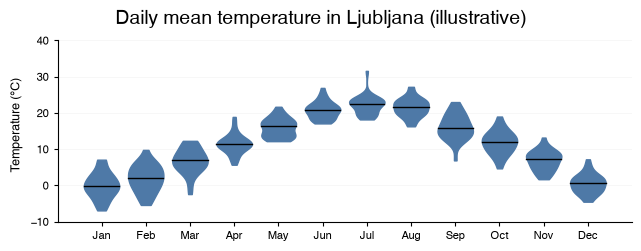

In [19]:
from datachart.constants import DATE_FORMAT

ViolinPlot(
    data=daily_temperatures,
    inner=VIOLIN_INNER.MEDIAN,
    title="Daily mean temperature in Ljubljana (illustrative)",
    ylabel="Temperature (°C)",
    # print the month labels as abbreviated month names
    xticks_format="%b",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Violins with boxes and swarms

The violin shows the shape, a box plot the standard summary, and a swarm plot every single observation; one chart rarely needs all three, but a figure that must convince a skeptical reader sometimes does. A violin plot draws its groups at the same positions as a [BoxPlot](../../../references/charts/boxplot/#datachart.charts.BoxPlot) or a [SwarmPlot](../../../references/charts/swarmplot/#datachart.charts.SwarmPlot) with the same labels, so [Panel](../../../references/utils/#datachart.utils.Panel) overlays them: the violin with `inner=None` supplies the body, the box plot drawn over it supplies the whiskers and outliers. A panel takes one violin plot, and all its figures must group the same labels in the same order. The [Panel](../../utility/panel/) guide covers the rest.

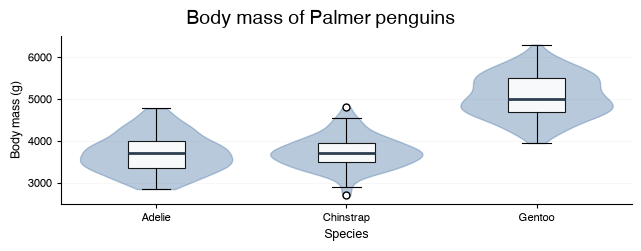

In [20]:
from datachart.charts import BoxPlot, SwarmPlot
from datachart.utils import Panel

Panel(
    [
        # the body only; the box plot supplies the summary
        ViolinPlot(data=penguins, inner=None, style={"plot_violin_alpha": 0.4}),
        BoxPlot(
            data=penguins,
            style={"plot_box_color": "#ffffff", "plot_box_alpha": 0.9, "plot_box_width": 0.15},
        ),
    ],
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel_left="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

A swarm plot draws every bird as a point, so the reader can check that the smoothed body is not inventing structure. The points draw over the body, so a faded body keeps them legible:

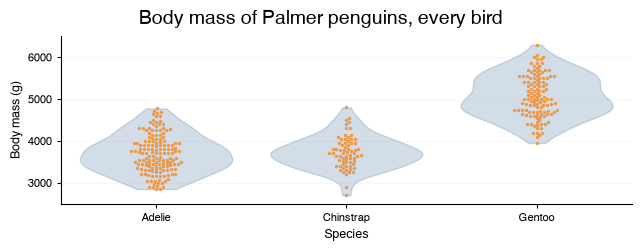

In [21]:
Panel(
    [
        # the body only, faded behind the points
        ViolinPlot(data=penguins, inner=None, style={"plot_violin_alpha": 0.25}),
        SwarmPlot(data=penguins, style={"plot_swarm_size": 6}),
    ],
    title="Body mass of Palmer penguins, every bird",
    xlabel="Species",
    ylabel_left="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

## Multiple Violin Plots

To compare several datasets, pass a list of lists to `data`: each inner list is one dataset, drawn in its own subplot, and `subplots=True` is required (violins of two datasets cannot share one axes; to compare two subgroups within each violin, use [split](#split-violins)). The per-chart attributes (`subtitle`, `style`) become lists aligned with the datasets; `title`, `xlabel` and `ylabel` stay global. Body mass and flipper length are different quantities, so each subplot carries its unit in its subtitle, and a style per chart keeps them apart.

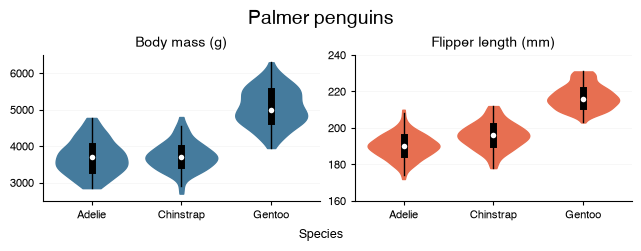

In [22]:
ViolinPlot(
    # one dataset per subplot
    data=[penguins, flippers],
    # a subtitle and a style per subplot
    subtitle=["Body mass (g)", "Flipper length (mm)"],
    style=[{"plot_violin_color": "#457b9d"}, {"plot_violin_color": "#e76f51"}],
    title="Palmer penguins",
    xlabel="Species",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # draw each dataset in its own subplot
    subplots=True,
).show()

### Shared axes across subplots

Subplots side by side invite comparison, and shared axes make it fair. `sharex` and `sharey` put the subplots on one axis, which is then labeled once, on the outer subplots; `max_cols` limits the subplots per row, and `max_cols=1` stacks them. The two datasets have different units, so only the group axis can be shared: with horizontal violins the species sit on the y-axis, and `sharey=True` labels them once, next to the left subplot.

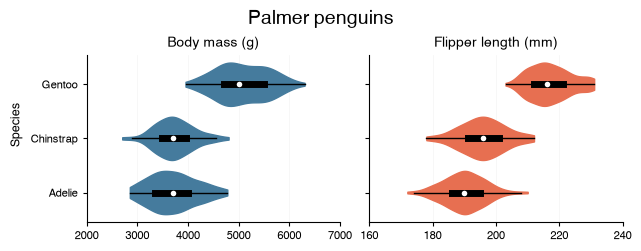

In [23]:
ViolinPlot(
    data=[penguins, flippers],
    subtitle=["Body mass (g)", "Flipper length (mm)"],
    style=[{"plot_violin_color": "#457b9d"}, {"plot_violin_color": "#e76f51"}],
    orientation=ORIENTATION.HORIZONTAL,
    title="Palmer penguins",
    ylabel="Species",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.X,
    subplots=True,
    # at most two subplots per row, one species axis for both
    max_cols=2,
    sharey=True,
).show()

## Additional Features

### Axis scales

Waiting times, file sizes and incomes are skewed: most values are small and a few are huge, so on a linear axis the bodies are squashed against zero with a long thin tail. `scaley` takes a [SCALE](../../../references/constants/#datachart.constants.SCALE) member, and a logarithmic axis spreads the small values out. Body masses are not skewed, so this example switches dataset: `first_reply`, defined in a hidden cell, holds 200 illustrative first-reply times (in minutes) of support requests per channel, from a seeded generator. On the linear axis only the forum body is visible; on the log axis all three are, minutes to days on one axis. The body is still estimated from the raw values, though, so on the log axis it keeps a linear-space shape: a flat, wide base and a thin spike toward the long tail.

In [24]:
rng = np.random.RandomState(42)

# illustrative median first-reply time (minutes) and log spread per support channel
CHANNELS = {"Chat": (4, 0.8), "Email": (180, 0.9), "Forum": (900, 1.0)}
first_reply = [
    {"label": channel, "value": float(minutes)}
    for channel, (median, spread) in CHANNELS.items()
    for minutes in rng.lognormal(np.log(median), spread, 200)
]

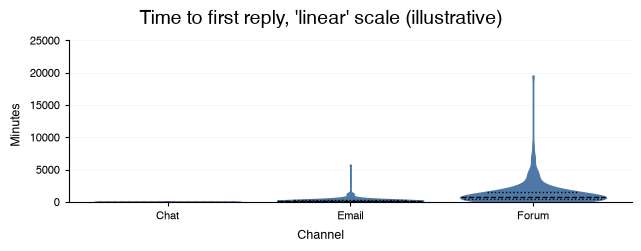

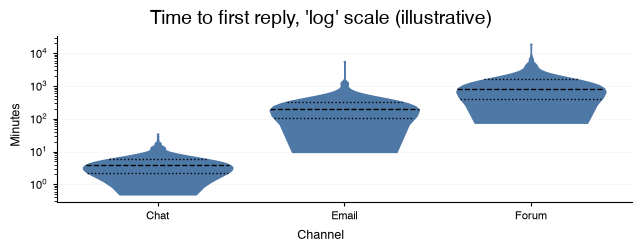

In [25]:
from datachart.constants import SCALE

for scale in [SCALE.LINEAR, SCALE.LOG]:
    ViolinPlot(
        data=first_reply,
        inner=VIOLIN_INNER.QUARTILES,
        title=f"Time to first reply, '{scale}' scale (illustrative)",
        xlabel="Channel",
        ylabel="Minutes",
        figsize=FIG_SIZE.FULL_SHORT,
        show_grid=SHOW_GRID.Y,
        # the scale of the value axis
        scaley=scale,
    ).show()

When the shape on the log scale matters, estimate the body on that scale: take the base-10 logarithm of the values, keep the linear axis, and put the original units back with `yticks` and `yticklabels` (the two lists must have the same length). The bodies turn into smooth humps, and the forum requests turn out to wait anywhere from an hour to several days:

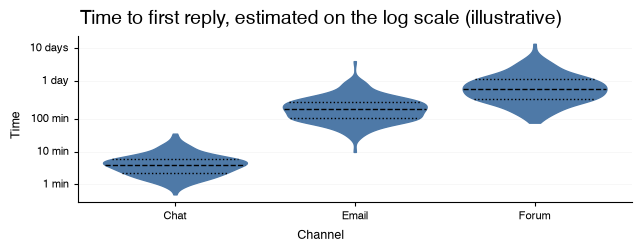

In [26]:
import math

log_reply = [{**point, "value": math.log10(point["value"])} for point in first_reply]

ViolinPlot(
    data=log_reply,
    inner=VIOLIN_INNER.QUARTILES,
    title="Time to first reply, estimated on the log scale (illustrative)",
    xlabel="Channel",
    ylabel="Time",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # ticks at powers of ten, labeled in the original units
    yticks=[0, 1, 2, math.log10(1440), math.log10(14400)],
    yticklabels=["1 min", "10 min", "100 min", "1 day", "10 days"],
).show()

### Custom data keys

Data that comes from a file or an API rarely uses the `label` and `value` keys, and renaming every record just to plot it is a chore. Instead, tell `ViolinPlot` which keys to read with the `label` and `value` arguments. `penguin_records` stores the birds the way a CSV export would, with a `species` and a `body_mass_g` key:

In [27]:
penguin_records = [
    {"species": group["species"], "sex": group["sex"], "body_mass_g": mass}
    for group in PENGUINS
    for mass in group["body_mass"]
]
penguin_records[:2]

[{'species': 'Adelie', 'sex': 'Female', 'body_mass_g': 3800},
 {'species': 'Adelie', 'sex': 'Female', 'body_mass_g': 3250}]

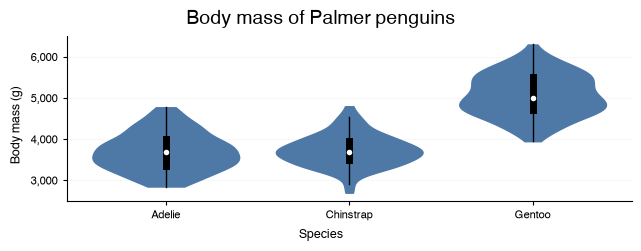

In [28]:
ViolinPlot(
    data=penguin_records,
    # the keys that hold the group and the value
    label="species",
    value="body_mass_g",
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

## Real-World Examples

The examples below put the features above to work on real or realistic data, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: What the Box Hides (Bimodal Response Times, Quartile Lines, and a Box Overlay in a Grid)

`response_times` holds the illustrative response time (in ms) of 300 requests to each of three services, from a seeded generator. Catalog and Search answer some requests from a cache and the rest from the database, so their times have two modes, fast cache hits and slow misses, with almost nothing in between; Checkout never uses the cache. A box plot reduces each service to a median and a spread, and for Catalog and Search the box stretches across the empty gap between the two modes. The left chart shows the two humps with quartile lines, the right one draws the box over a faded body, and [Grid](../../utility/grid/) puts them side by side on one value axis.

In [29]:
rng = np.random.RandomState(42)

# (share of cache hits, cache hit ms, database ms) of each service
SERVICES = {
    "Catalog": (0.7, 12, 140),
    "Search": (0.4, 20, 180),
    "Checkout": (0.0, 1, 95),
}
N_REQUESTS = 300

response_times = []
for service, (hit_share, hit_ms, db_ms) in SERVICES.items():
    hits = rng.rand(N_REQUESTS) < hit_share
    fast = rng.lognormal(np.log(hit_ms), 0.2, N_REQUESTS)
    slow = rng.lognormal(np.log(db_ms), 0.25, N_REQUESTS)
    response_times += [{"label": service, "value": float(ms)} for ms in np.where(hits, fast, slow)]

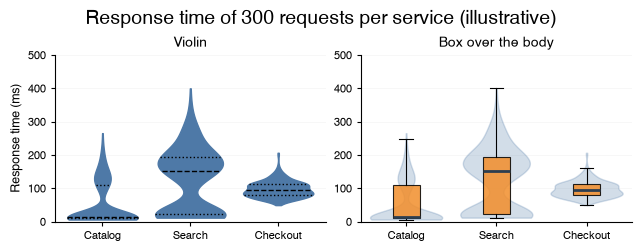

In [30]:
from datachart.utils import Grid

violins = ViolinPlot(
    data=response_times,
    # quartile lines keep the two humps visible
    inner=VIOLIN_INNER.QUARTILES,
    title="Violin",
    ylabel="Response time (ms)",
    show_grid=SHOW_GRID.Y,
)
boxes = Panel(
    [
        ViolinPlot(data=response_times, inner=None, style={"plot_violin_alpha": 0.25}),
        BoxPlot(data=response_times, show_outliers=False),
    ],
    title="Box over the body",
    show_grid=SHOW_GRID.Y,
)

Grid(
    [[violins, boxes]],
    title=f"Response time of {N_REQUESTS} requests per service (illustrative)",
    figsize=FIG_SIZE.FULL_SHORT,
    sharey=True,
).show()

### Example 2: Does the Validation Winner Hold Up on Test? (Split Violins, Value Labels, and an Emphasis Rule)

`benchmark` holds the illustrative accuracy of four models, each trained with 20 random seeds and evaluated on the validation and the test split, from a seeded generator. Split by the evaluation split, each violin shows how much of a model's score is seed noise (the height of the body) and how much it drops from validation to test (the offset between the halves). The medians are printed on each half, and `emphasis_rule={"top": 2}` keeps the two contenders with the best median in view while the rest are muted. Deep looks best on validation but drops on test; Deep + aug. holds its score.

In [31]:
rng = np.random.RandomState(42)

# (validation mean, test mean, standard deviation) of each model's accuracy
MODELS = {
    "Baseline": (0.812, 0.805, 0.020),
    "Wide": (0.838, 0.831, 0.015),
    "Deep": (0.871, 0.842, 0.025),
    "Deep + aug.": (0.866, 0.861, 0.012),
}
N_SEEDS = 20

benchmark = [
    {"label": model, "split": split, "value": float(accuracy)}
    for model, (val_mean, test_mean, std) in MODELS.items()
    for split, center in [("validation", val_mean), ("test", test_mean)]
    for accuracy in rng.normal(center, std, N_SEEDS)
]

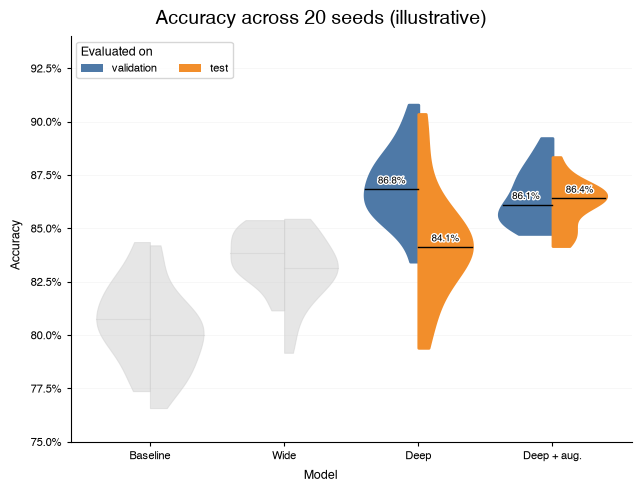

In [32]:
from datachart.constants import VALUE_FORMAT

ViolinPlot(
    data=benchmark,
    # validation on the left, test on the right
    split="split",
    inner=VIOLIN_INNER.MEDIAN,
    show_legend=True,
    legend={"title": "Evaluated on", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    # the median accuracy of each half
    show_values=True,
    value_format=VALUE_FORMAT.PERCENT,
    style={"plot_value_fontsize": 7},
    # the two models with the best median accuracy
    emphasis_rule={"top": 2},
    title=f"Accuracy across {N_SEEDS} seeds (illustrative)",
    xlabel="Model",
    ylabel="Accuracy",
    yticks_format=VALUE_FORMAT.PERCENT,
    ymax=0.94,
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
).show()

### Example 3: Can a Scale Tell the Species Apart? (Violins and Swarms in Panels, Notes, and a Grid)

A field team without a bill gauge has a scale and a ruler: can body mass or flipper length alone tell the three Palmer species apart? The shared `penguins` and `flippers` data answer it. Each measurement gets a panel of faded violins with every bird drawn over them as a swarm, a note says what the panel shows, and [Grid](../../utility/grid/) stacks the two panels so the answer reads top to bottom: both measurements separate the Gentoo from the rest, but the Adelie and Chinstrap bodies overlap almost completely in mass and largely in flipper length.

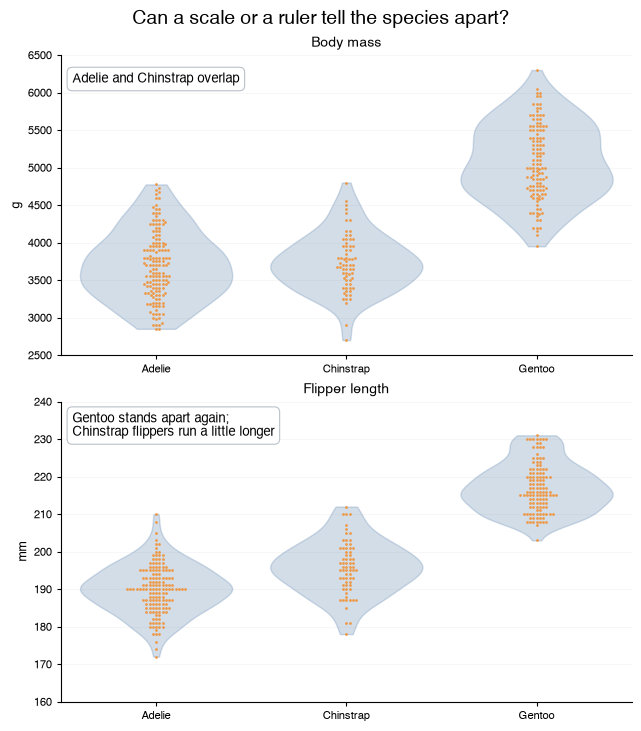

In [33]:
def measurement_panel(data, title, unit, note):
    # faded violins with every bird on top, and a note on what it shows
    return Panel(
        [
            ViolinPlot(
                data=data,
                inner=None,
                style={"plot_violin_alpha": 0.25},
                texts={"text": note, "x": 0.02, "y": 0.92, "coords": "axes"},
            ),
            SwarmPlot(data=data, style={"plot_swarm_size": 4}),
        ],
        title=title,
        ylabel_left=unit,
        show_grid=SHOW_GRID.Y,
    )


Grid(
    [
        [measurement_panel(penguins, "Body mass", "g", "Adelie and Chinstrap overlap")],
        [measurement_panel(flippers, "Flipper length", "mm", "Gentoo stands apart again;\nChinstrap flippers run a little longer")],
    ],
    title="Can a scale or a ruler tell the species apart?",
    figsize=FIG_SIZE.FULL_TALL,
).show()